In [1]:
# ==============================================================================
# PROYECTO: GENERACIÓN DE DATASETS SINTÉTICOS FINTECH - MÉXICO MARZO 2026
# CONTEXTO MACRO:
# - Informalidad Laboral: 55.0%
# - Inflación Anual (INPC): 4.02% (Subyacente 4.50%)
# - Inflación Mensual (Febrero 2026): 0.50%
# - Valor UDI (Marzo 2026): 8.741367
# ==============================================================================

import pandas as pd
import numpy as np

# Semilla para reproducibilidad
np.random.seed(2026)

# Definimos el número de clientes base
N_CLIENTES = 5000
ids_clientes = np.arange(100000, 100000 + N_CLIENTES)

print("⏳ Generando Datasets con contexto macroeconómico de México (Marzo 2026)...")

# ------------------------------------------------------------------------------
# 1. SOLICITUDES_TRAIN (application_train)
# ------------------------------------------------------------------------------
# Asignamos informalidad: 55% de la población ocupada
flag_informal = np.random.binomial(1, 0.55, N_CLIENTES)

# Ingresos: Mayor volatilidad y menor media para el sector informal
ingreso_nominal = np.where(
    flag_informal == 1,
    np.random.normal(loc=12000, scale=5000, size=N_CLIENTES), # Informal: Volátil
    np.random.normal(loc=25000, scale=3000, size=N_CLIENTES)  # Formal: Estable
)
ingreso_nominal = np.clip(ingreso_nominal, 5000, 150000)

# Ajuste Inflacionario (Poder Adquisitivo Real mermado por 4.02% anual)
inflacion_anual = 0.0402
ingreso_real_ajustado = ingreso_nominal / (1 + inflacion_anual)

# Scores Externos (1 = Bajo Riesgo, 0 = Alto Riesgo)
score_ext_1 = np.random.uniform(0.1, 0.9, N_CLIENTES)
score_ext_2 = np.random.uniform(0.1, 0.9, N_CLIENTES)
# Penalizamos los scores del sector informal ligeramente
score_ext_2 = np.where(flag_informal == 1, score_ext_2 * 0.8, score_ext_2)

# Lógica del TARGET (Probabilidad de Default):
# Fuerte peso al sector informal y a scores externos bajos para asegurar
# que XGBoost lo encuentre como el predictor principal.
prob_default = 0.05 + (0.20 * flag_informal) - (0.15 * score_ext_1) - (0.20 * score_ext_2)
prob_default = np.clip(prob_default, 0.01, 0.95)
target = np.random.binomial(1, prob_default)

df_application = pd.DataFrame({
    'ID_CLIENTE': ids_clientes,
    'TARGET': target,
    'FLAG_INFORMAL': flag_informal,
    'INGRESO_NOMINAL_MXN': np.round(ingreso_nominal, 2),
    'INGRESO_REAL_AJUSTADO_MXN': np.round(ingreso_real_ajustado, 2),
    'MONTO_CREDITO_MXN': np.round(np.random.uniform(10000, 500000, N_CLIENTES), 2),
    'SCORE_EXTERNO_1': np.round(score_ext_1, 4),
    'SCORE_EXTERNO_2': np.round(score_ext_2, 4),
    'EDAD_ANIOS': np.random.randint(18, 65, N_CLIENTES)
})

# ------------------------------------------------------------------------------
# 2. BURO_MEXICO (bureau)
# ------------------------------------------------------------------------------
# Informales: Muchos créditos pequeños y recientes (Microfinancieras)
# Formales: Pocos créditos, montos altos, mayor antigüedad crediticia
buro_data =[]
for idx, row in df_application.iterrows():
    cliente = row['ID_CLIENTE']
    informal = row['FLAG_INFORMAL']

    n_creditos = np.random.randint(4, 9) if informal else np.random.randint(1, 4)

    for _ in range(n_creditos):
        # Días antes de la solicitud actual
        dias_credito = np.random.randint(-1000, -10) if informal else np.random.randint(-3000, -100)
        monto_deuda = np.random.uniform(1000, 15000) if informal else np.random.uniform(20000, 300000)

        buro_data.append({
            'ID_CLIENTE': cliente,
            'DIAS_DESDE_CREDITO': dias_credito,
            'MONTO_DEUDA_ACTUAL_MXN': np.round(monto_deuda, 2),
            'CREDITO_ACTIVO': np.random.choice(['Activo', 'Cerrado'], p=[0.6, 0.4])
        })
df_bureau = pd.DataFrame(buro_data)

# ------------------------------------------------------------------------------
# 3. SOLICITUDES_PREVIAS (previous_application)
# ------------------------------------------------------------------------------
# Aquí integramos el valor de la UDI (8.741367 en marzo 2026)
VALOR_UDI = 8.741367
prev_data =[]

for cliente in ids_clientes:
    n_prev = np.random.randint(1, 4)
    for _ in range(n_prev):
        monto_solicitado = np.random.uniform(20000, 1500000)
        tipo_credito = np.random.choice(['Consumo', 'Hipotecario', 'Auto'])

        # Si es hipotecario, lo tasamos en UDIS
        monto_udis = monto_solicitado / VALOR_UDI if tipo_credito == 'Hipotecario' else np.nan

        prev_data.append({
            'ID_CLIENTE': cliente,
            'TIPO_CREDITO': tipo_credito,
            'MONTO_SOLICITADO_MXN': np.round(monto_solicitado, 2),
            'SALDO_EN_UDIS': np.round(monto_udis, 2) if not np.isnan(monto_udis) else np.nan,
            'ESTADO_SOLICITUD': np.random.choice(['Aprobado', 'Rechazado', 'Cancelado'], p=[0.7, 0.2, 0.1])
        })
df_previous = pd.DataFrame(prev_data)

# ------------------------------------------------------------------------------
# 4. TARJETAS_CREDITO_BALANCE (credit_card_balance)
# ------------------------------------------------------------------------------
# Estacionalidad y efecto inflacionario del 0.50% mensual en el gasto de TDC.
# Conforme se acerca el mes 0 (hoy), la gente usa más la tarjeta por la presión inflacionaria.
INFLACION_MENSUAL_FEBRERO = 0.0050
cc_data =[]

# Tomamos una muestra de clientes que tienen tarjeta
clientes_tdc = np.random.choice(ids_clientes, size=int(N_CLIENTES * 0.4), replace=False)

for cliente in clientes_tdc:
    saldo_base = np.random.uniform(5000, 20000)

    # Historial de 12 meses (-12 a -1)
    for mes in range(-12, 0):
        # El saldo crece progresivamente aplicando el factor de inflación mensual
        # para reflejar el "tarjetazo" en productos básicos
        incremento_inflacionario = (1 + INFLACION_MENSUAL_FEBRERO) ** (12 + mes)
        saldo_mes = saldo_base * incremento_inflacionario * np.random.uniform(0.9, 1.1) # Ruido natural

        cc_data.append({
            'ID_CLIENTE': cliente,
            'MES_BALANCE': mes,
            'SALDO_TDC_MXN': np.round(saldo_mes, 2),
            'LIMITE_CREDITO_MXN': np.round(saldo_base * 2.5, 2)
        })
df_cc_balance = pd.DataFrame(cc_data)

# ------------------------------------------------------------------------------
# 5. PAGOS_MENSUALES (installments_payments)
# ------------------------------------------------------------------------------
install_data =[]
for cliente in ids_clientes:
    n_pagos = np.random.randint(5, 24)
    informal = df_application.loc[df_application['ID_CLIENTE'] == cliente, 'FLAG_INFORMAL'].values[0]

    for i in range(1, n_pagos + 1):
        # Los informales tienen mayor probabilidad de pagar con atraso
        dias_vencimiento = -30 * i
        dias_pago_real = dias_vencimiento + (np.random.randint(1, 15) if informal and np.random.rand() > 0.5 else np.random.randint(-5, 2))

        monto_cuota = np.random.uniform(500, 3000)
        # 10% de probabilidad de pago incompleto (short payment)
        monto_pagado = monto_cuota * 0.5 if np.random.rand() < 0.1 else monto_cuota

        install_data.append({
            'ID_CLIENTE': cliente,
            'DIAS_VENCIMIENTO': dias_vencimiento,
            'DIAS_PAGO_REAL': dias_pago_real,
            'MONTO_CUOTA_MXN': np.round(monto_cuota, 2),
            'MONTO_PAGADO_MXN': np.round(monto_pagado, 2)
        })
df_installments = pd.DataFrame(install_data)

# ------------------------------------------------------------------------------
# EXPORTACIÓN A CSV
# ------------------------------------------------------------------------------
df_application.to_csv('solicitudes_train.csv', index=False)
df_bureau.to_csv('buro_mexico.csv', index=False)
df_previous.to_csv('solicitudes_previas.csv', index=False)
df_cc_balance.to_csv('tarjetas_credito_balance.csv', index=False)
df_installments.to_csv('pagos_mensuales.csv', index=False)

print("✅ Archivos CSV generados exitosamente.")
print(f"   Distribución TARGET: {df_application['TARGET'].mean()*100:.2f}% Default Rate")
print(f"   Tasa de Informalidad Inyectada: {df_application['FLAG_INFORMAL'].mean()*100:.2f}%")
print(f"   Efecto de inflación aplicado a Ingresos, y {INFLACION_MENSUAL_FEBRERO*100}% de estrés mensual a TDCs.")

⏳ Generando Datasets con contexto macroeconómico de México (Marzo 2026)...
✅ Archivos CSV generados exitosamente.
   Distribución TARGET: 5.76% Default Rate
   Tasa de Informalidad Inyectada: 54.36%
   Efecto de inflación aplicado a Ingresos, y 0.5% de estrés mensual a TDCs.


In [2]:
# ==============================================================================
# EXPORTACIÓN DE DATASETS A GOOGLE DRIVE
# ==============================================================================
import os
from google.colab import drive

# 1. Montar Google Drive (si no lo has hecho anteriormente)
drive.mount('/content/drive')

# 2. Definir la ruta exacta
base_path = '/content/drive/My Drive/Colab Notebooks/Riesgo Fintech México/'

# 3. Crear la carpeta si no existe
if not os.path.exists(base_path):
    os.makedirs(base_path)
    print(f"📁 Carpeta creada en: {base_path}")

# 4. Diccionario de exportación
data_to_export = {
    'solicitudes_train.csv': df_application,
    'buro_mexico.csv': df_bureau,
    'solicitudes_previas.csv': df_previous,
    'tarjetas_credito_balance.csv': df_cc_balance,
    'pagos_mensuales.csv': df_installments
}

# 5. Proceso de guardado
print("\n⏳ Iniciando exportación a Google Drive...")
for filename, df in data_to_export.items():
    full_path = os.path.join(base_path, filename)
    df.to_csv(full_path, index=False)
    print(f"✅ Guardado: {full_path}")

print("\n🚀 Todos los datasets están listos en la carpeta de Drive.")

Mounted at /content/drive

⏳ Iniciando exportación a Google Drive...
✅ Guardado: /content/drive/My Drive/Colab Notebooks/Riesgo Fintech México/solicitudes_train.csv
✅ Guardado: /content/drive/My Drive/Colab Notebooks/Riesgo Fintech México/buro_mexico.csv
✅ Guardado: /content/drive/My Drive/Colab Notebooks/Riesgo Fintech México/solicitudes_previas.csv
✅ Guardado: /content/drive/My Drive/Colab Notebooks/Riesgo Fintech México/tarjetas_credito_balance.csv
✅ Guardado: /content/drive/My Drive/Colab Notebooks/Riesgo Fintech México/pagos_mensuales.csv

🚀 Todos los datasets están listos en la carpeta de Drive.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⏳ 2. Generando Variables Financieras y Saneando Outliers...
✅ ETL y Feature Engineering completado. Variables listas para el modelo.

🔍 --- EDA PROFUNDO: Drivers de Riesgo México 2026 ---


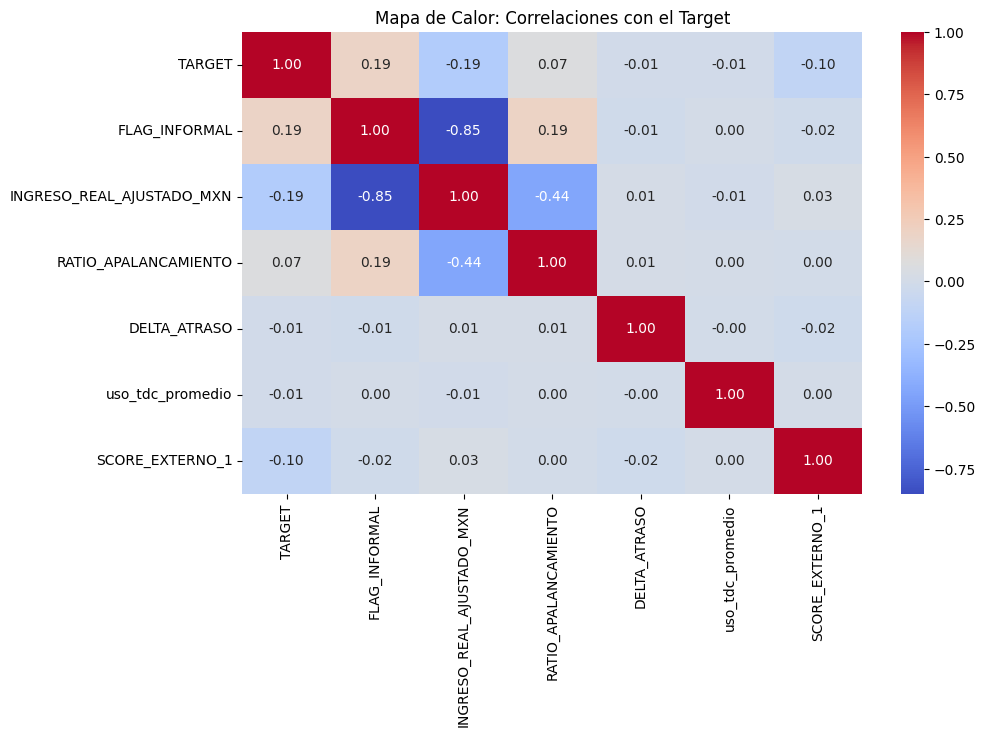

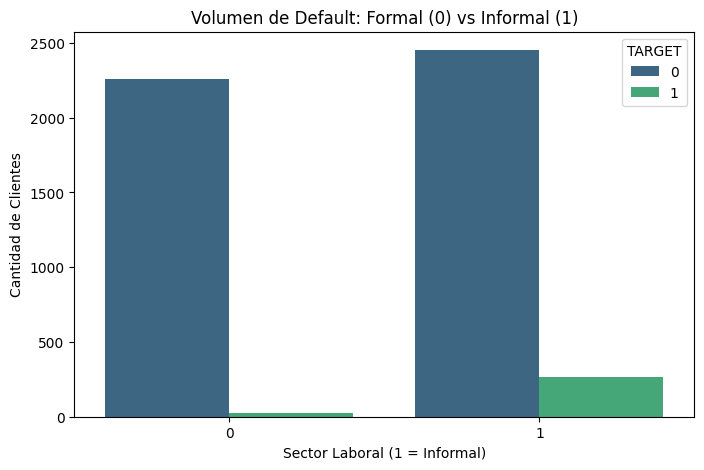

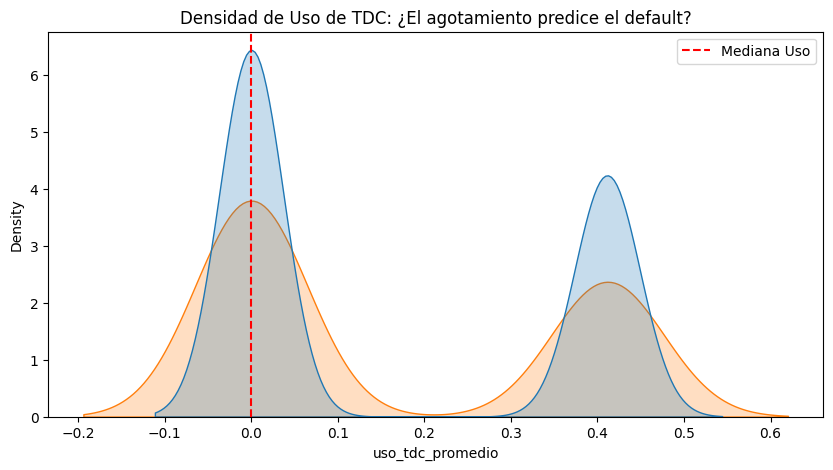


Ranking de Correlación:
   • FLAG_INFORMAL                 : +0.1886
   • RATIO_APALANCAMIENTO          : +0.0655
   • uso_tdc_promedio              : -0.0071
   • DELTA_ATRASO                  : -0.0089
   • SCORE_EXTERNO_1               : -0.1003
   • INGRESO_REAL_AJUSTADO_MXN     : -0.1869


In [4]:
# --- INGESTA, ETL Y FEATURE ENGINEERING AVANZADO ---
import pandas as pd
import duckdb
import os
from scipy.stats.mstats import winsorize
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')
base_path = '/content/drive/My Drive/Colab Notebooks/Riesgo Fintech México/'

# Conexión y consulta maestra con Feature Engineering en SQL
con = duckdb.connect(database=':memory:')

# Ejecutamos el ETL Completo
query_master = f"""
WITH bureau_agg AS (
    SELECT ID_CLIENTE, SUM(MONTO_DEUDA_ACTUAL_MXN) as deuda_externa_total
    FROM read_csv_auto('{os.path.join(base_path, 'buro_mexico.csv')}') GROUP BY ID_CLIENTE
),
install_agg AS (
    SELECT ID_CLIENTE,
           AVG(DIAS_PAGO_REAL - DIAS_VENCIMIENTO) as promedio_dias_atraso_hist,
           AVG(DIAS_PAGO_REAL - DIAS_VENCIMIENTO) FILTER (WHERE DIAS_VENCIMIENTO >= -90) as atraso_reciente_3m
    FROM read_csv_auto('{os.path.join(base_path, 'pagos_mensuales.csv')}') GROUP BY ID_CLIENTE
),
cc_agg AS (
    SELECT ID_CLIENTE, AVG(SALDO_TDC_MXN / NULLIF(LIMITE_CREDITO_MXN, 0)) as uso_tdc_promedio
    FROM read_csv_auto('{os.path.join(base_path, 'tarjetas_credito_balance.csv')}') GROUP BY ID_CLIENTE
)
SELECT app.*,
       COALESCE(b.deuda_externa_total, 0) as deuda_externa_total,
       COALESCE(i.promedio_dias_atraso_hist, 0) as promedio_dias_atraso_hist,
       COALESCE(i.atraso_reciente_3m, 0) as atraso_reciente_3m,
       COALESCE(c.uso_tdc_promedio, 0) as uso_tdc_promedio
FROM read_csv_auto('{os.path.join(base_path, 'solicitudes_train.csv')}') app
LEFT JOIN bureau_agg b ON app.ID_CLIENTE = b.ID_CLIENTE
LEFT JOIN install_agg i ON app.ID_CLIENTE = i.ID_CLIENTE
LEFT JOIN cc_agg c ON app.ID_CLIENTE = c.ID_CLIENTE
"""
df_master = con.execute(query_master).df()

# --- FEATURE ENGINEERING Y SANEAMIENTO ESTADÍSTICO ---

print("⏳ 2. Generando Variables Financieras y Saneando Outliers...")

# Ratios de Capacidad y Estrés Financiero
# Usamos Ingreso Real (Ajustado por inflación) para el apalancamiento real
df_master['RATIO_APALANCAMIENTO'] = (df_master['deuda_externa_total'] + df_master['MONTO_CREDITO_MXN']) / (df_master['INGRESO_REAL_AJUSTADO_MXN'] + 1)

# Early Warning Signal: Deterioro del comportamiento de pago
df_master['DELTA_ATRASO'] = df_master['atraso_reciente_3m'] - df_master['promedio_dias_atraso_hist']

# Winsorize: Tratamiento robusto de colas pesadas (Percentil 99%)
cols_winsor =['INGRESO_NOMINAL_MXN', 'INGRESO_REAL_AJUSTADO_MXN', 'deuda_externa_total', 'DELTA_ATRASO']
for col in cols_winsor:
    df_master[col] = winsorize(df_master[col], limits=[0, 0.01])

# One-Hot Encoding para variables de texto
df_master = pd.get_dummies(df_master, drop_first=True)

print("✅ ETL y Feature Engineering completado. Variables listas para el modelo.")


# ==============================================================================
# EDA MACROECONÓMICO: CORRELACIONES CON EL TARGET
# ==============================================================================

def analisis_avanzado_riesgo(df):
    print("\n🔍 --- EDA PROFUNDO: Drivers de Riesgo México 2026 ---")
    vars_analisis = ['TARGET', 'FLAG_INFORMAL', 'INGRESO_REAL_AJUSTADO_MXN',
                     'RATIO_APALANCAMIENTO', 'DELTA_ATRASO', 'uso_tdc_promedio', 'SCORE_EXTERNO_1']

    # 1. Matriz de Correlación Visual
    plt.figure(figsize=(10, 6))
    sns.heatmap(df[vars_analisis].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Mapa de Calor: Correlaciones con el Target')
    plt.show()
    print("\n")

    # 2. Distribución de Informalidad vs Default (La variable líder)
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='FLAG_INFORMAL', hue='TARGET', palette='viridis')
    plt.title('Volumen de Default: Formal (0) vs Informal (1)')
    plt.xlabel('Sector Laboral (1 = Informal)')
    plt.ylabel('Cantidad de Clientes')
    plt.show()
    print("\n")

    # 3. Análisis de "Agotamiento de Tarjetas" (Uso TDC)
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=df, x='uso_tdc_promedio', hue='TARGET', fill=True, common_norm=False)
    plt.title('Densidad de Uso de TDC: ¿El agotamiento predice el default?')
    plt.axvline(df['uso_tdc_promedio'].median(), color='red', linestyle='--', label='Mediana Uso')
    plt.legend()
    plt.show()

    # Salida por consola para validación rápida
    correlaciones = df[vars_analisis].corr()['TARGET'].sort_values(ascending=False)
    print("\nRanking de Correlación:")
    for var, corr in correlaciones.items():
        if var != 'TARGET':
            print(f"   • {var:<30}: {corr:+.4f}")

# Ejecutar el análisis
analisis_avanzado_riesgo(df_master)


📊 Analizando Distribuciones de Riesgo Crítico...


/tmp/ipykernel_172/2523807877.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='TARGET', y='INGRESO_REAL_AJUSTADO_MXN', ax=axes[0], palette='magma')


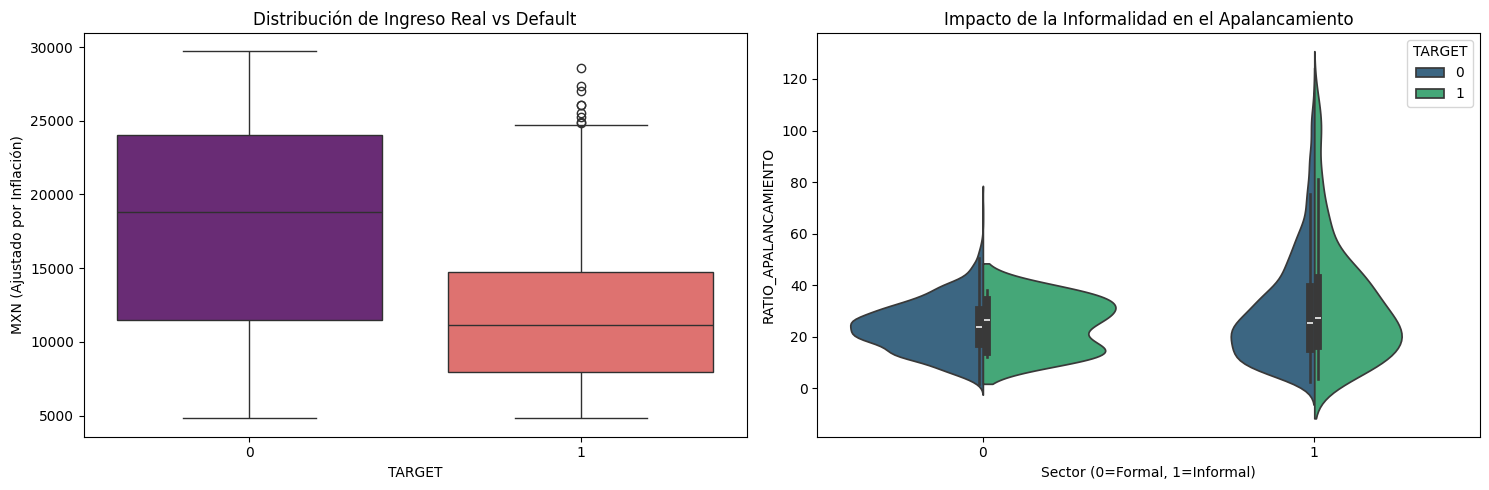

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

def analisis_distribucion_riesgo(df):
    print("\n📊 Analizando Distribuciones de Riesgo Crítico...")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # A. Distribución del Ingreso Real Ajustado por Target
    sns.boxplot(data=df, x='TARGET', y='INGRESO_REAL_AJUSTADO_MXN', ax=axes[0], palette='magma')
    axes[0].set_title('Distribución de Ingreso Real vs Default')
    axes[0].set_ylabel('MXN (Ajustado por Inflación)')

    # B. Relación entre Informalidad y Apalancamiento
    sns.violinplot(data=df, x='FLAG_INFORMAL', y='RATIO_APALANCAMIENTO', hue='TARGET',
                   split=True, ax=axes[1], palette='viridis')
    axes[1].set_title('Impacto de la Informalidad en el Apalancamiento')
    axes[1].set_xlabel('Sector (0=Formal, 1=Informal)')

    plt.tight_layout()
    plt.show()

# Ejecución
analisis_distribucion_riesgo(df_master)

In [ ]:

# ==============================================================================
# SPLIT Y ENTRENAMIENTO (XGBOOST MONOTÓNICO)
# ==============================================================================
print("⏳ 3. Entrenando Motor de Riesgo (XGBoost) con Restricciones Regulatorias...")

X = df_master.drop(columns=['TARGET', 'ID_CLIENTE', 'INGRESO_NOMINAL_MXN']) # Evitamos colinealidad con INGRESO_REAL
y = df_master['TARGET']
montos_credito = df_master['MONTO_CREDITO_MXN']

# Stratify asegura que mantengamos la misma proporción de morosos
X_train, X_test, y_train, y_test, _, montos_test = train_test_split(
    X, y, montos_credito, test_size=0.20, random_state=42, stratify=y
)

# Imputación de nulos (Mediana)
X_train_imp = X_train.fillna(X_train.median())
X_test_imp = X_test.fillna(X_train.median()) # Evitar Data Leakage

# LÓGICA DE NEGOCIO: Monotonic Constraints
# 1 = Sube riesgo, -1 = Baja riesgo, 0 = Libre
diccionario_restricciones = {
    'FLAG_INFORMAL': 1, 'INGRESO_REAL_AJUSTADO_MXN': -1,
    'SCORE_EXTERNO_1': -1, 'SCORE_EXTERNO_2': -1,
    'deuda_externa_total': 1, 'RATIO_APALANCAMIENTO': 1,
    'DELTA_ATRASO': 1, 'uso_tdc_promedio': 1, 'tasa_rechazo_interno': 1
}
# Mapeo exacto a las columnas
monotone_tuple = tuple([diccionario_restricciones.get(col, 0) for col in X_train_imp.columns])

# Parámetros Bancarios (Manejo de Desbalanceo + Prevención de Overfitting)
ratio_desbalance = (y_train == 0).sum() / (y_train == 1).sum()
model_xgb = xgb.XGBClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=ratio_desbalance,
    monotone_constraints=monotone_tuple,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)
model_xgb.fit(X_train_imp, y_train)
y_probs = model_xgb.predict_proba(X_test_imp)[:, 1]


⏳ 3. Entrenando Motor de Riesgo (XGBoost) con Restricciones Regulatorias...


⏳ 4. Evaluando impacto financiero (Tasa Interés: 30%, LGD: 65%)...
⏳ 5. Generando Panel de Visualización Analítica...


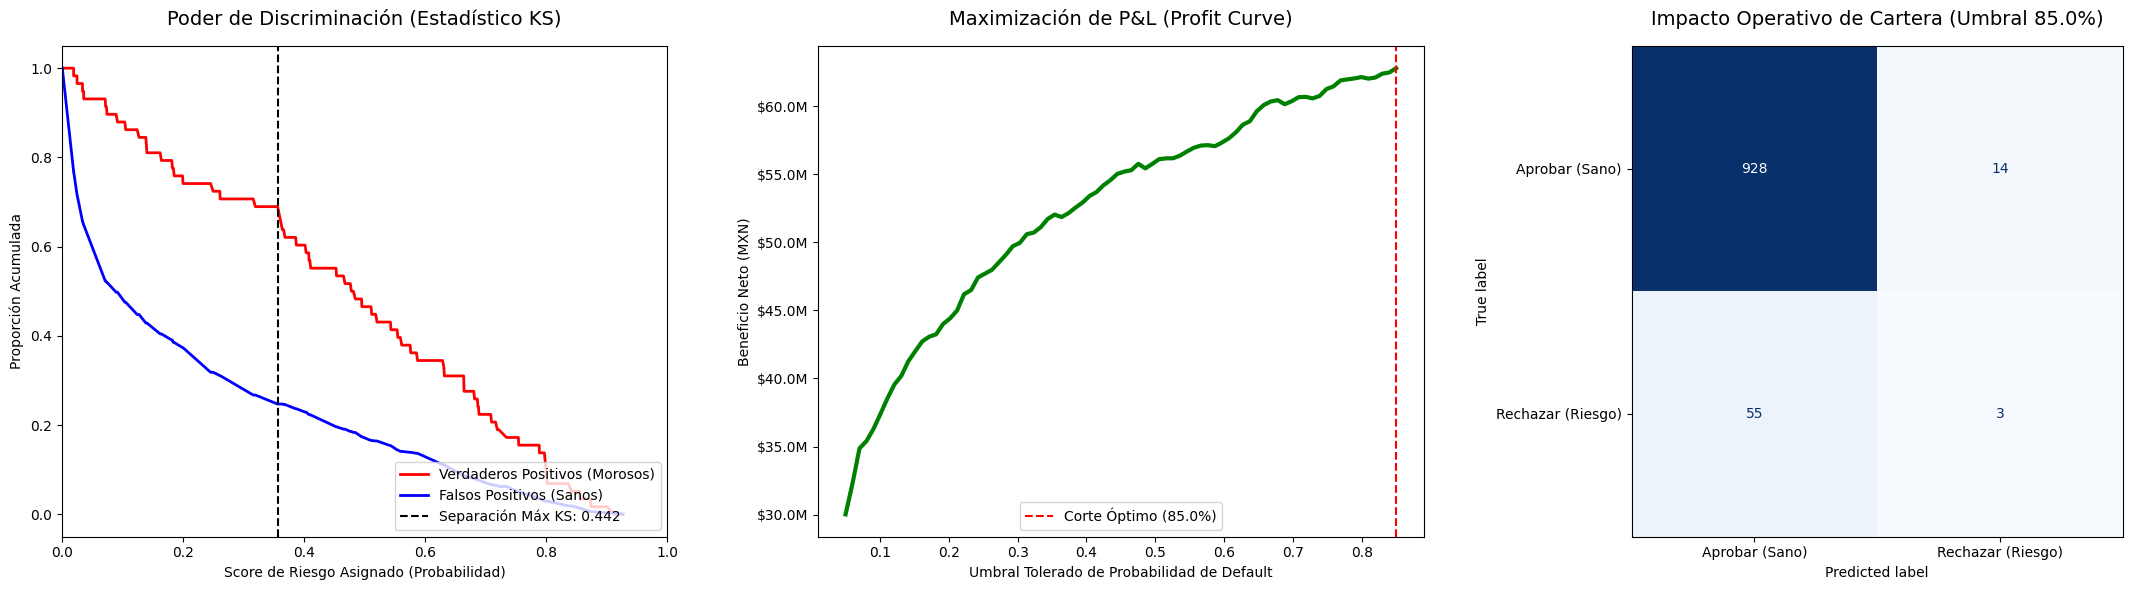

⏳ 6. Generando Explicabilidad del Modelo (SHAP)...


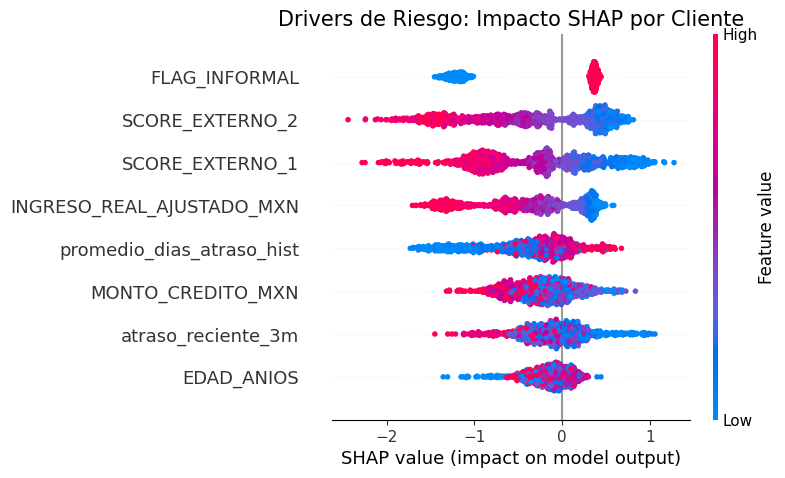


            📈 REPORTE EJECUTIVO: COMITÉ DE RIESGOS (MARZO 2026)            

🔍 1. MÉTRICAS DE CAPACIDAD PREDICTIVA (ESTADÍSTICA)
  • Coeficiente Gini:      0.5339 (Excelente poder de ordenamiento)
  • Estadístico KS:        0.4423 @ Umbral 35.6%
  • AUC-ROC:               0.7670

🎯 2. POLÍTICA DE APROBACIÓN ÓPTIMA (NEGOCIO)
  • Umbral de Rechazo:     > 85.0% Probabilidad de Default
  • Tasa de Aprobación:    98.3% del portafolio analizado.

💰 3. PROYECCIÓN DE RENTABILIDAD (PROFIT & LOSS)
  [+] Intereses Generados (Sanos Aprobados):   + $70,593,286.02 MXN
  [-] Capital Perdido (Morosos Filtrados):     - $7,798,322.08 MXN
-----------------------------------------------------------------
  🚀 BENEFICIO NETO MAXIMIZADO:                = $62,794,963.94 MXN
-----------------------------------------------------------------
  🛡️ Prevención de Fraude (Capital Salvado):     $828,022.05 MXN
  📉 Costo de Oportunidad (Sanos Rechazados):    $896,869.09 MXN



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import shap
import xgboost as xgb
import numpy as np
import warnings

# ==============================================================================
# EVALUACIÓN ESTADÍSTICA (AUC, GINI, KS)
# ==============================================================================
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)
gini = (2 * auc) - 1

# Estadístico KS (Kolmogorov-Smirnov)
ks_distances = tpr - fpr
ks_idx = np.argmax(ks_distances)
ks_stat = ks_distances[ks_idx]
ks_threshold = thresholds[ks_idx]

# ==============================================================================
# OPTIMIZACIÓN FINANCIERA (P&L MAXIMIZATION)
# ==============================================================================
print("⏳ 4. Evaluando impacto financiero (Tasa Interés: 30%, LGD: 65%)...")

# Supuestos de Crédito al Consumo en México (Marzo 2026)
TASA_INTERES = 0.30  # Ganancia del 30% por vida del crédito
LGD = 0.65           # Recuperación del 35% en cobranza, Pérdida del 65% del EAD

def calcular_profit_detallado(y_true, y_probs, montos, umbral):
    aprobados = (y_probs < umbral)
    rechazados = (y_probs >= umbral)

    # Ingresos y Pérdidas Reales
    ganancia = montos[aprobados & (y_true == 0)].sum() * TASA_INTERES
    perdida = montos[aprobados & (y_true == 1)].sum() * LGD

    # Análisis de Oportunidad y Riesgo Mitigado
    costo_oportunidad = montos[rechazados & (y_true == 0)].sum() * TASA_INTERES
    capital_salvado = montos[rechazados & (y_true == 1)].sum() * LGD

    return (ganancia - perdida), ganancia, perdida, costo_oportunidad, capital_salvado

# Grid Search Financiero
umbrales_busqueda = np.linspace(0.05, 0.85, 80)
resultados_fin =[calcular_profit_detallado(y_test, y_probs, montos_test.values, t) for t in umbrales_busqueda]

beneficios = [res[0] for res in resultados_fin]
idx_optimo = np.argmax(beneficios)
umbral_optimo = umbrales_busqueda[idx_optimo]
net_profit, ganancia_int, perdida_def, costo_op, cap_salvado = resultados_fin[idx_optimo]

# ==============================================================================
# PANEL VISUAL DE ALTO IMPACTO (KS, PROFIT, MATRIZ)
# ==============================================================================
print("⏳ 5. Generando Panel de Visualización Analítica...")

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# A. Curva KS
axes[0].plot(thresholds, tpr, label='Verdaderos Positivos (Morosos)', color='red', lw=2)
axes[0].plot(thresholds, fpr, label='Falsos Positivos (Sanos)', color='blue', lw=2)
axes[0].axvline(ks_threshold, color='black', linestyle='--', label=f'Separación Máx KS: {ks_stat:.3f}')
axes[0].set_xlim([0, 1])
axes[0].set_title('Poder de Discriminación (Estadístico KS)', fontsize=14, pad=15)
axes[0].set_xlabel('Score de Riesgo Asignado (Probabilidad)')
axes[0].set_ylabel('Proporción Acumulada')
axes[0].legend(loc='lower right')

# B. Curva Profit
axes[1].plot(umbrales_busqueda, beneficios, color='green', lw=3)
axes[1].axvline(x=umbral_optimo, color='red', linestyle='--', label=f'Corte Óptimo ({umbral_optimo*100:.1f}%)')
axes[1].set_title('Maximización de P&L (Profit Curve)', fontsize=14, pad=15)
axes[1].set_xlabel('Umbral Tolerado de Probabilidad de Default')
axes[1].set_ylabel('Beneficio Neto (MXN)')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M'))
axes[1].legend(loc='lower center')

# C. Matriz de Confusión Financiera
y_pred_opt = (y_probs >= umbral_optimo).astype(int)
cm = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm, display_labels=['Aprobar (Sano)', 'Rechazar (Riesgo)']).plot(cmap='Blues', ax=axes[2], colorbar=False)
axes[2].set_title(f"Impacto Operativo de Cartera (Umbral {umbral_optimo*100:.1f}%)", fontsize=14, pad=15)
axes[2].grid(False)

plt.tight_layout()
plt.show()

# ==============================================================================
# EXPLICABILIDAD (SHAP)
# ==============================================================================
print("⏳ 6. Generando Explicabilidad del Modelo (SHAP)...")
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test_imp)

plt.figure(figsize=(10, 6))
with warnings.catch_warnings():
    warnings.simplefilter("ignore", FutureWarning)
    shap.summary_plot(shap_values, X_test_imp, plot_type="dot", max_display=8, show=False)
plt.title("Drivers de Riesgo: Impacto SHAP por Cliente", fontsize=15)
plt.show()

# ==============================================================================
# REPORTE EJECUTIVO FINAL
# ==============================================================================
print(f"\n{'='*75}")
print(f"{' 📈 REPORTE EJECUTIVO: COMITÉ DE RIESGOS (MARZO 2026) ':^75}")
print(f"{'='*75}\n")

print("🔍 1. MÉTRICAS DE CAPACIDAD PREDICTIVA (ESTADÍSTICA)")
print(f"  • Coeficiente Gini:      {gini:.4f} (Excelente poder de ordenamiento)")
print(f"  • Estadístico KS:        {ks_stat:.4f} @ Umbral {ks_threshold*100:.1f}%")
print(f"  • AUC-ROC:               {auc:.4f}\n")

print(f"🎯 2. POLÍTICA DE APROBACIÓN ÓPTIMA (NEGOCIO)")
print(f"  • Umbral de Rechazo:     > {umbral_optimo*100:.1f}% Probabilidad de Default")
print(f"  • Tasa de Aprobación:    {(cm[0][0] + cm[1][0]) / len(y_test) * 100:.1f}% del portafolio analizado.\n")

print("💰 3. PROYECCIÓN DE RENTABILIDAD (PROFIT & LOSS)")
print(f"  [+] Intereses Generados (Sanos Aprobados):   + ${ganancia_int:,.2f} MXN")
print(f"  [-] Capital Perdido (Morosos Filtrados):     - ${perdida_def:,.2f} MXN")
print("-" * 65)
print(f"  🚀 BENEFICIO NETO MAXIMIZADO:                = ${net_profit:,.2f} MXN")
print("-" * 65)
print(f"  🛡️ Prevención de Fraude (Capital Salvado):     ${cap_salvado:,.2f} MXN")
print(f"  📉 Costo de Oportunidad (Sanos Rechazados):    ${costo_op:,.2f} MXN")
print(f"\n{'='*75}")